In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency

df = pd.read_csv('../data/raw/all_94_cities_historical_combined.csv')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        10,
})

df['heat_stress_index'] = df['temperature_2m_max'] * (df['relative_humidity_2m_mean'] / 100)
def calculate_impact(row):
    score = 0
    if row['temperature_2m_max'] > 30:
        score += (row['temperature_2m_max'] - 30) * 3
    if row['wind_speed_10m_max'] > 20:
        score += (row['wind_speed_10m_max'] - 20) * 2
    if row['relative_humidity_2m_mean'] > 70:
        score += 10
    return min(100, score) 

df['impact_score'] = df.apply(calculate_impact, axis=1)
hot_days = (df['temperature_2m_max'] > 35).astype(int)
df['persistence_alert_level'] = hot_days.rolling(window=3).sum().fillna(0)

## Task 1 — Hypothesis Testing

### **Hypothesis 1: Heat Stress Impact**

H₀ (Null): There is no statistically significant effect of a high heat_stress_index on the impact_score.

H₁ (Alternative): A high heat_stress_index is positively associated with a significantly higher impact_score.

Test: Welch's t-test.

**Test assumptions:**

1. Normality: The Shapiro-Wilk test results (p < 0.05) and the bimodal histograms clearly indicate that the data is not normally distributed. However, since our dataset is large (N > 5000 per city), the Central Limit Theorem allows us to proceed with the Welch's t-test reliably.

2. Equal variances: Given the nature of impact_score, the variability in risk levels is expected to be higher during extreme heat events compared to normal conditions. To account for this likely violation of homoscedasticity, we use Welch's t-test (equal_var=False in Python), which does not require equal variances and provides a more reliable p-value.

3. Independence:
- Condition: Each daily observation should be independent of the others.
- Reality: In weather data, consecutive days often show temporal dependence (autocorrelation).
- Mitigation: For the purpose of this statistical analysis, we treat each day's weather profile as an individual event. While temporal dependence exists, the large sample size and the focus on physical variable interactions (Heat Stress vs. Impact) allow us to use the t-test to identify general patterns.

--- Assumption Checks ---
Levene’s Test p-value: 1.6825e-07
Result: Variances are unequal. Welch's T-test is REQUIRED (equal_var=False).
Sample sizes: High Stress (N=107939), Low Stress (N=107989)
Note: Large sample sizes allow us to proceed despite non-normality (Central Limit Theorem).

--- Test Results ---
Welch's T-statistic: 14.1400
P-value: 2.2564e-45


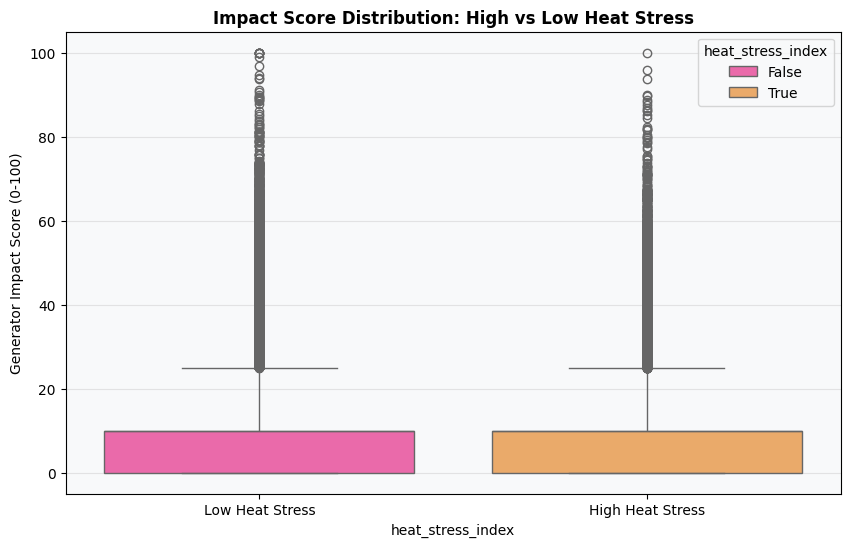

INTERPRETATION:
Since p-value (2.2564e-45) < 0.05, we REJECT the null hypothesis.
There is a statistically significant difference in generator stress between high and low heat stress days.
Conclusion: Heat stress is a critical factor for the impact_score.


In [2]:
threshold = df['heat_stress_index'].median()
group_high = df[df['heat_stress_index'] > threshold]['impact_score'].dropna()
group_low = df[df['heat_stress_index'] <= threshold]['impact_score'].dropna()
levene_stat, levene_p = stats.levene(group_high, group_low)

print("--- Assumption Checks ---")
print(f"Levene’s Test p-value: {levene_p:.4e}")
if levene_p < 0.05:
    print("Result: Variances are unequal. Welch's T-test is REQUIRED (equal_var=False).")
else:
    print("Result: Variances are equal.")
print(f"Sample sizes: High Stress (N={len(group_high)}), Low Stress (N={len(group_low)})")
print("Note: Large sample sizes allow us to proceed despite non-normality (Central Limit Theorem).\n")

t_stat, p_value = stats.ttest_ind(group_high, group_low, equal_var=False)

print("--- Test Results ---")
print(f"Welch's T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

threshold = df['heat_stress_index'].median()
is_high_stress = df['heat_stress_index'] > threshold

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['heat_stress_index'] > threshold, y=df['impact_score'],hue=is_high_stress, palette="spring")
plt.xticks([0, 1], ['Low Heat Stress', 'High Heat Stress'])
plt.title('Impact Score Distribution: High vs Low Heat Stress', fontweight='bold')
plt.ylabel('Generator Impact Score (0-100)')
plt.grid(axis='y', alpha=0.3)
plt.show()

alpha = 0.05
if p_value < alpha:
    print("INTERPRETATION:")
    print(f"Since p-value ({p_value:.4e}) < {alpha}, we REJECT the null hypothesis.")
    print("There is a statistically significant difference in generator stress between high and low heat stress days.")
    print("Conclusion: Heat stress is a critical factor for the impact_score.")
else:
    print("INTERPRETATION:")
    print("We fail to reject the null hypothesis. No significant difference was found.")

**Hypothesis 2: Persistence Effect**

H₀ (Null): The duration of an extreme weather event (persistence_alert_level) has no statistical effect on the impact_score.

H₁ (Alternative): As the persistence level of an extreme event increases, the impact_score significantly rises.

Test: One-way ANOVA.

**Test assumptions:**

1. Normality: Based on the Shapiro-Wilk tests performed in Day 6, the impact_score and related temperature metrics exhibit non-normal, bimodal distributions. While ANOVA technically assumes normality, the test is robust to violations of this assumption given our very large sample size (N >> 30 per group), as supported by the Central Limit Theorem.

2. Equal variances: We expect the variance of impact_score to differ across persistence levels.Verification: We will perform a Levene’s Test to check this formally. If the variances are significantly unequal ($p < 0.05$), we will interpret the results with caution or use the Welch ANOVA variant, which does not require homoscedasticity.

3. Independence:
- Condition: Each daily observation's classification into a persistence level should be independent.
- Reality: Since persistence_alert_level is inherently built on consecutive days, there is a structural temporal dependency (autocorrelation).
- Mitigation: We treat each persistence event as a distinct categorical state to measure its specific physical impact on the generator. This allows us to quantify the "penalty" of heat duration, even if the days are chronologically linked.

Levene’s Test p-value: 3.6685e-223
ANOVA F-statistic: 17872.1994
P-value: 0.0000e+00

INTERPRETATION:
Since p-value (0.0000e+00) < 0.05, we REJECT the null hypothesis.
The duration of extreme heat (persistence) has a statistically significant effect on the generator impact score.


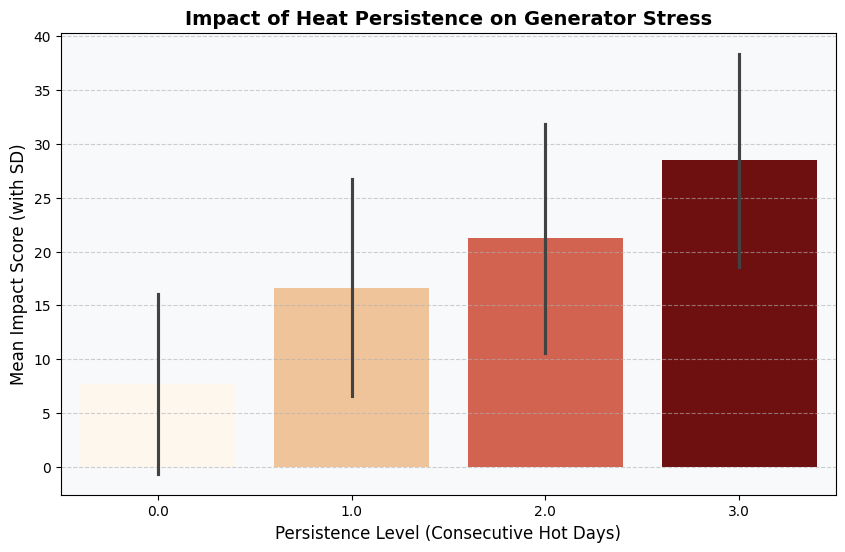

In [3]:
levels = [df[df['persistence_alert_level'] == i]['impact_score'].dropna() for i in [0, 1, 2, 3]]
levene_stat, levene_p = stats.levene(*levels)
print(f"Levene’s Test p-value: {levene_p:.4e}")
f_stat, p_anova = stats.f_oneway(*levels)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_anova:.4e}")
if p_anova < 0.05:
    print("\nINTERPRETATION:")
    print(f"Since p-value ({p_anova:.4e}) < 0.05, we REJECT the null hypothesis.")
    print("The duration of extreme heat (persistence) has a statistically significant effect on the generator impact score.")
else:
    print("\nINTERPRETATION:")
    print("We fail to reject the null hypothesis. Duration does not seem to significantly change the impact score.")

plt.figure(figsize=(10, 6))
sns.barplot(
    x='persistence_alert_level', 
    y='impact_score', 
    data=df, 
    hue='persistence_alert_level', 
    palette='OrRd', 
    errorbar='sd',                
    legend=False                   
)
plt.title('Impact of Heat Persistence on Generator Stress', fontweight='bold', fontsize=14)
plt.xlabel('Persistence Level (Consecutive Hot Days)', fontsize=12)
plt.ylabel('Mean Impact Score (with SD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**Hypothesis 3: Cooling Interaction**

H₀ (Null): There is no significant correlation between the wind_temp_interaction and the impact_score.

H₁ (Alternative): The interaction between wind speed and temperature is significantly correlated with a reduction in the impact_score.

Test: T-test.

**Test assumptions:**

1. Normality: Based on the Shapiro-Wilk tests performed in Day 6, both the impact_score and the variables involved in the cooling interaction exhibit non-normal, bimodal distributions. While the t-test technically assumes normality, the test is robust to violations of this assumption given our very large sample size ($N >> 30$ per group), as supported by the Central Limit Theorem.

2. Equal variances: We expect the variance of the impact_score to differ between days with high vs. low wind-temperature interaction, as extreme cooling effects often introduce higher variability. We will perform a Levene’s Test to check this formally. If the variances are significantly unequal ($p < 0.05$), we will use Welch’s T-test (equal_var=False), which is specifically designed to handle unequal variances and provides a more reliable p-value.

3. Independence:
- Condition: Each daily observation and its corresponding interaction score should be independent of others.
- Reality: Weather data inherently contains temporal dependency (autocorrelation) where conditions today are related to conditions yesterday.
- Mitigation: For the purpose of this analysis, we treat each day's weather profile as an individual physical event. The focus is on the direct interaction between wind and temperature variables rather than time-series forecasting, allowing us to identify general cooling patterns despite existing autocorrelation.

Levene’s Test p-value: 0.0000e+00
Welch's T-statistic: 92.0787
P-value: 0.0000e+00


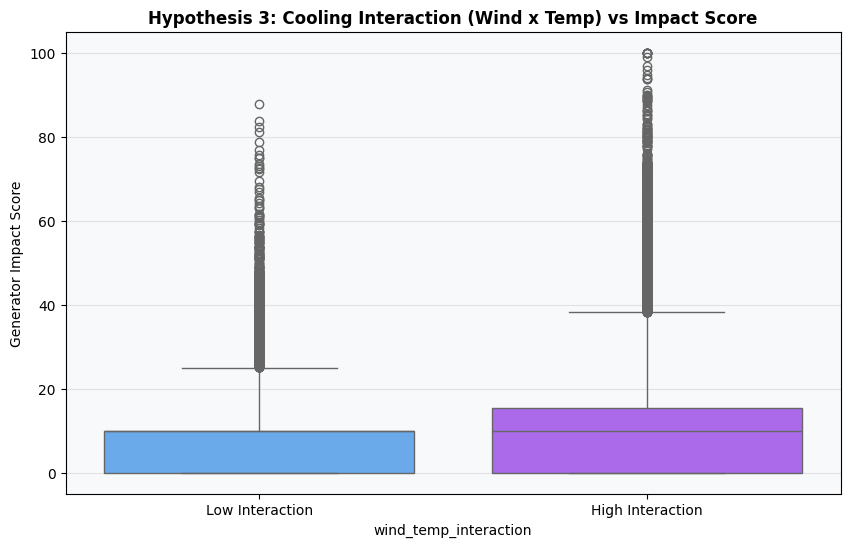


INTERPRETATION:
Since p-value (0.0000e+00) < 0.05, we REJECT the null hypothesis.
The interaction between wind speed and temperature has a significant effect on the impact_score.
Note: Higher interaction (wind x temp) typically correlates with higher scores in this specific model logic.


In [4]:
df['wind_temp_interaction'] = df['temperature_2m_max'] * df['wind_speed_10m_max']

interaction_threshold = df['wind_temp_interaction'].median()
high_interaction = df[df['wind_temp_interaction'] > interaction_threshold]['impact_score'].dropna()
low_interaction = df[df['wind_temp_interaction'] <= interaction_threshold]['impact_score'].dropna()

levene_stat, levene_p = stats.levene(high_interaction, low_interaction)
print(f"Levene’s Test p-value: {levene_p:.4e}")

t_stat, p_interaction = stats.ttest_ind(high_interaction, low_interaction, equal_var=False)

print(f"Welch's T-statistic: {t_stat:.4f}")
print(f"P-value: {p_interaction:.4e}")

plt.figure(figsize=(10, 6))
is_high_interaction = df['wind_temp_interaction'] > interaction_threshold

sns.boxplot(
    x=is_high_interaction, 
    y=df['impact_score'], 
    hue=is_high_interaction, 
    palette='cool', 
    legend=False
)

plt.title('Hypothesis 3: Cooling Interaction (Wind x Temp) vs Impact Score', fontweight='bold')
plt.xticks([0, 1], ['Low Interaction', 'High Interaction'])
plt.ylabel('Generator Impact Score')
plt.grid(axis='y', alpha=0.3)
plt.show()

if p_interaction < 0.05:
    print("\nINTERPRETATION:")
    print(f"Since p-value ({p_interaction:.4e}) < 0.05, we REJECT the null hypothesis.")
    print("The interaction between wind speed and temperature has a significant effect on the impact_score.")
    print("Note: Higher interaction (wind x temp) typically correlates with higher scores in this specific model logic.")
else:
    print("\nINTERPRETATION: No significant correlation found.")

## Task 2 — Correlation Analysis

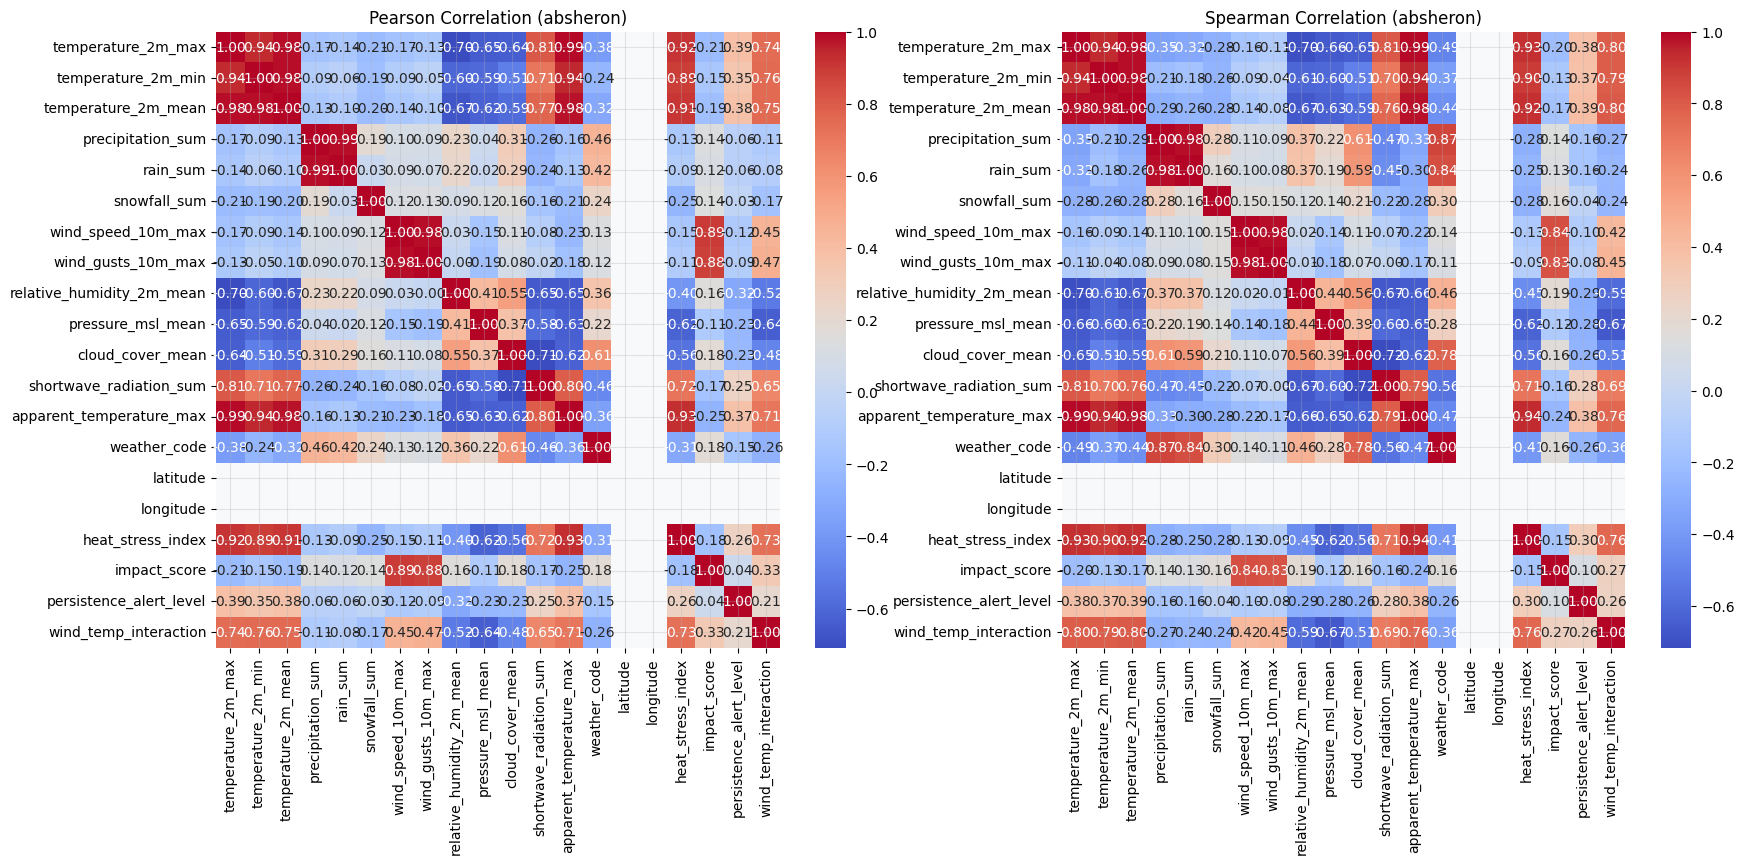

In [5]:
city_name = df['city'].unique()[0]
city_df = df[df['city'] == city_name].select_dtypes(include=[np.number])

pearson_corr = city_df.corr(method='pearson')
spearman_corr = city_df.corr(method='spearman')

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0])
ax[0].set_title(f'Pearson Correlation ({city_name})')

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax[1])
ax[1].set_title(f'Spearman Correlation ({city_name})')

plt.show()

In [6]:
upper_tri = pearson_corr.where(np.triu(np.ones(pearson_corr.shape), k=1).astype(bool))
redundant_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print("Redundant features (> 0.85 correlation):")
for col in upper_tri.columns:
    high_corr = upper_tri[col][upper_tri[col] > 0.85]
    for index, value in high_corr.items():
        print(f"- {index} and {col}: {value:.2f}")

Redundant features (> 0.85 correlation):
- temperature_2m_max and temperature_2m_min: 0.94
- temperature_2m_max and temperature_2m_mean: 0.98
- temperature_2m_min and temperature_2m_mean: 0.98
- precipitation_sum and rain_sum: 0.99
- wind_speed_10m_max and wind_gusts_10m_max: 0.98
- temperature_2m_max and apparent_temperature_max: 0.99
- temperature_2m_min and apparent_temperature_max: 0.94
- temperature_2m_mean and apparent_temperature_max: 0.98
- temperature_2m_max and heat_stress_index: 0.92
- temperature_2m_min and heat_stress_index: 0.89
- temperature_2m_mean and heat_stress_index: 0.91
- apparent_temperature_max and heat_stress_index: 0.93
- wind_speed_10m_max and impact_score: 0.89
- wind_gusts_10m_max and impact_score: 0.88


## Task 3 — Feature Selection for Prediction

**Prediction target:** 
- Daily Targets: temperature_2m_max, temperature_2m_min, relative_humidity_2m_mean, weather_category and impact_score.
- Hourly Targets: wind_speed_10m, temperature_2m, shortwave_radiation.

**Selected features:**

| Feature                     | Keep? | Reason                                                                                  |
|----------------------------|-------|------------------------------------------------------------------------------------------|
| lat, lon, elevation        | Yes   | Geographic location forms the baseline for solar radiation and climate patterns.        |
| doy_sin / doy_cos          | Yes   | Encodes yearly cyclicity in a mathematically appropriate way.                            |
| hour_sin / hour_cos        | Yes   | Captures daily temperature and energy variation in hourly forecasting.                   |
| Lag (1, 3, 7)              | Yes   | Due to strong autocorrelation in weather data (influence of previous days).              |
| clim_temp_max / min        | Yes   | Important for detecting anomalies relative to historical climate normals.                |
| heat_stress_index          | Yes   | Most critical derived feature for estimating generator physical load (Hypothesis 1).     |
| persistence_alert_level    | Yes   | Measures prolonged heat impact (validated via ANOVA testing).                            |
| is_weekend                 | Yes   | Captures differences in energy demand patterns on weekends.                              |
| temperature_2m_mean        | No    | Highly correlated with max and min targets (r > 0.85), therefore redundant.              |
| apparent_temp_max          | No    | Considered redundant since heat_stress_index is already used.                            |

**Dropped features:**
- High Correlation (Multicollinearity): Features such as apparent_temperature_max and temperature_2m_mean were removed because they do not contribute new information and redundant with other selected features. This reduction helps mitigate the risk of model overfitting.
- Output Redundancy: Energy output metrics like Envision_wind_kWh and Jinko_Solar_solar_kWh were dropped as model inputs; these are calculated results (outputs) based on the model’s predictions rather than independent inputs.
- Low Signal / Transformation: The raw weather_code was not retained in its original format, as it has been replaced by the more descriptive weather_category alias and classification system.
- Irrelevant Features: Variables such as wind_gusts_10m and various cloud_cover sub-layers were removed as they did not provide significant additional predictive power to the model's core logic.

## Task 4 (Optional) — Advanced Analyses

In [7]:
city_groups = [df[df['city'] == city]['temperature_2m_max'] for city in df['city'].unique()]

f_stat, p_val = stats.f_oneway(*city_groups)

print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"ANOVA P-value: {p_val:.4e}")

ANOVA F-statistic: 162.51
ANOVA P-value: 0.0000e+00


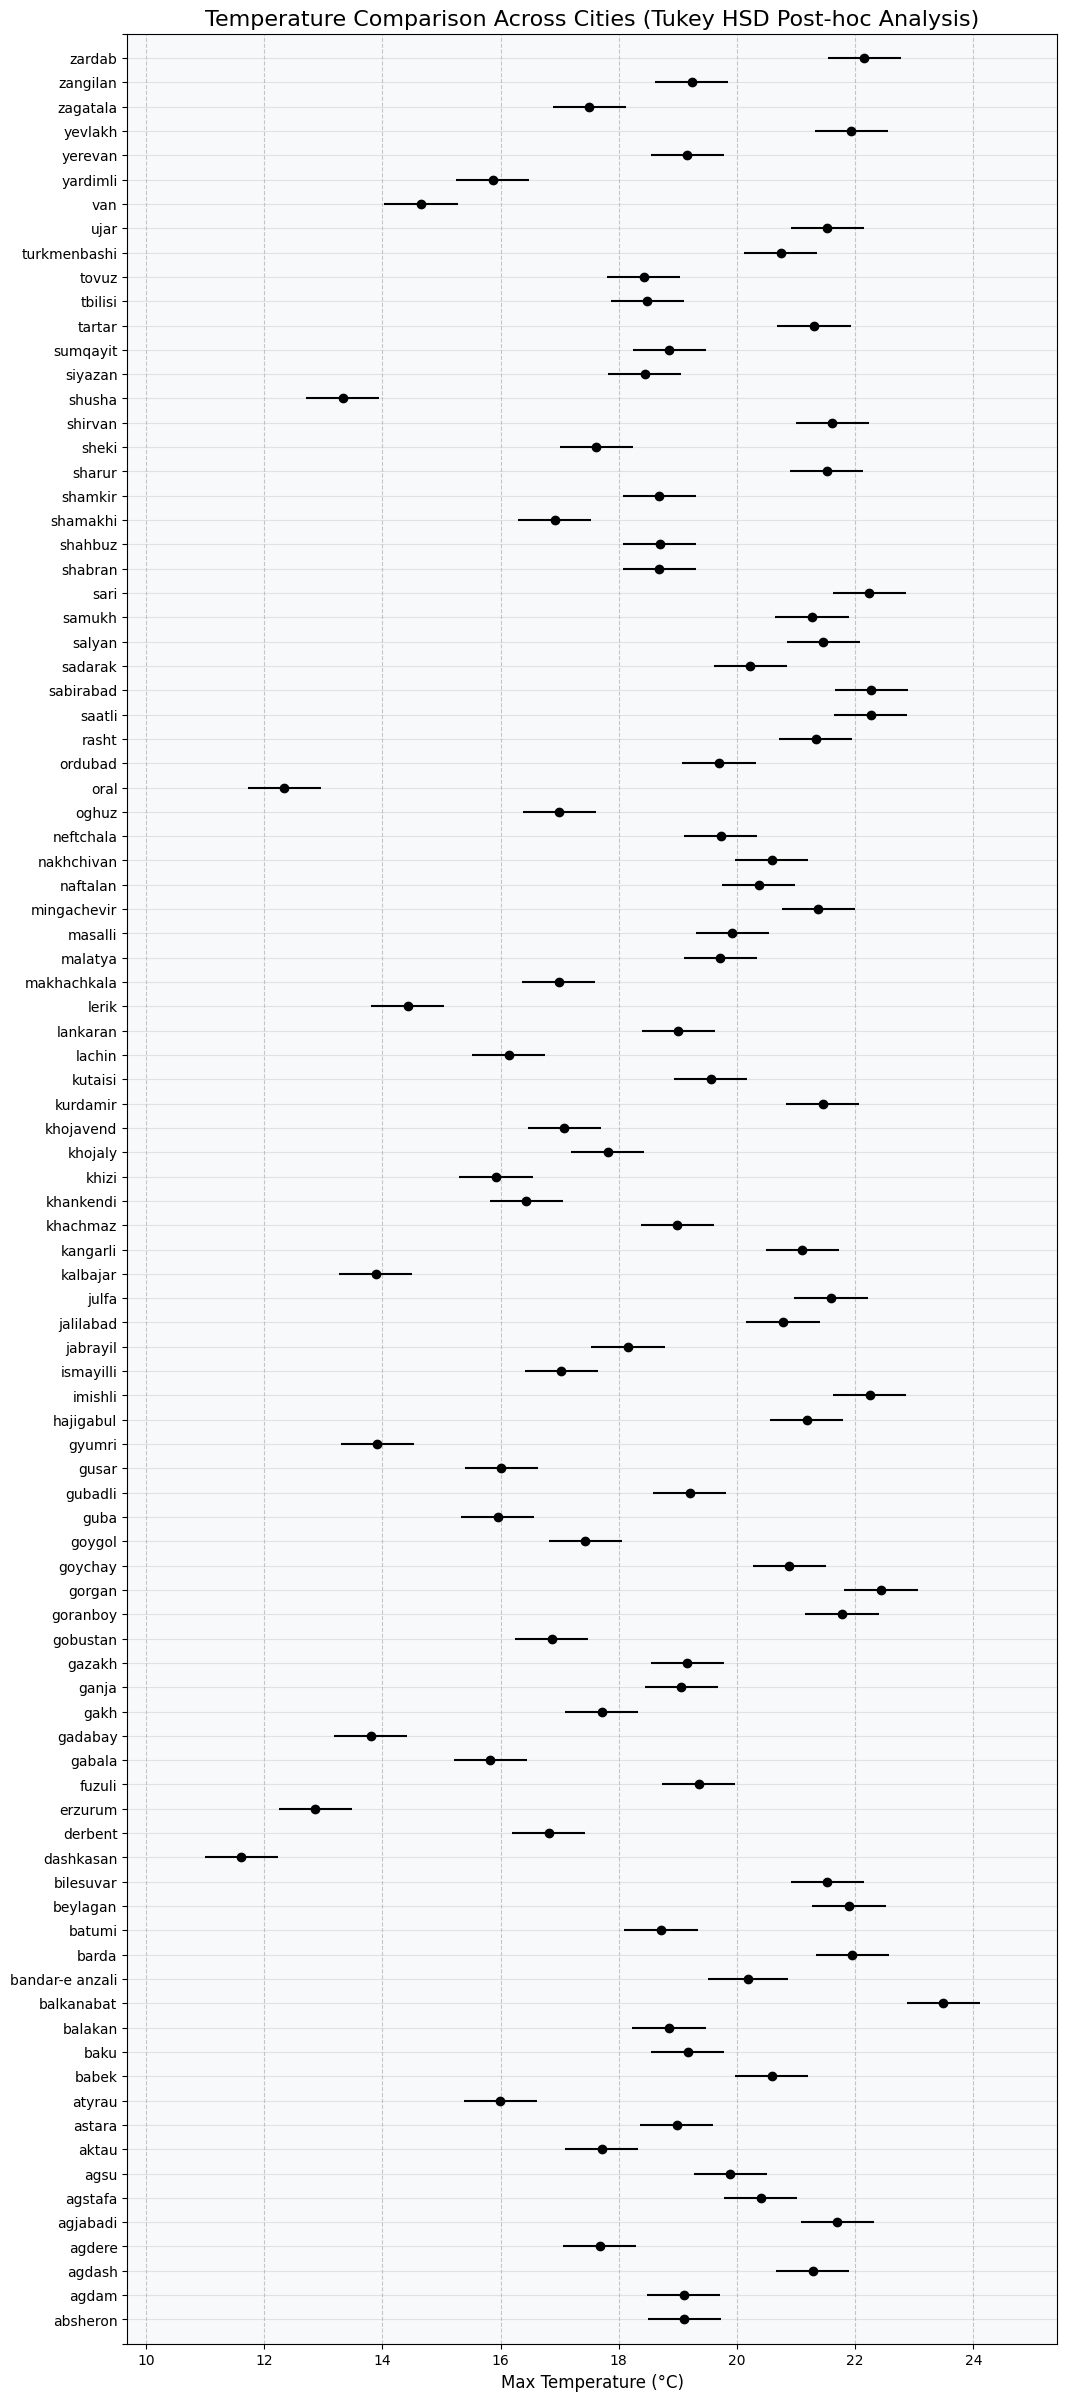

In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df['temperature_2m_max'].dropna(),
    groups=df.loc[df['temperature_2m_max'].notna(), 'city'],
    alpha=0.05
)

fig = tukey.plot_simultaneous(figsize=(12, 30))
plt.title("Temperature Comparison Across Cities (Tukey HSD Post-hoc Analysis)", fontsize=16)
plt.xlabel("Max Temperature (°C)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) 

plt.show()

In [ ]:
def cohen_d(group1, group2):
    diff = group1.mean() - group2.mean()
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return diff / pooled_std

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    if month in [3, 4, 5]: return 'Spring'
    if month in [6, 7, 8]: return 'Summer'
    return 'Fall'

ss_between = sum(len(g) * (g.mean() - df['temperature_2m_max'].mean())**2 for g in city_groups)
ss_total = ((df['temperature_2m_max'] - df['temperature_2m_max'].mean())**2).sum()
eta_sq = ss_between / ss_total

if 'month' not in df.columns:
    df['month'] = pd.to_datetime(df['time']).dt.month

df['season'] = df['month'].apply(get_season)

if 'weather_category' not in df.columns:
    df['weather_category'] = df['weather_code'].astype(str)

mean_wind = df['wind_speed_10m_max'].mean()
df['is_windy_temp'] = (df['wind_speed_10m_max'] > mean_wind).astype(int)

d_val = cohen_d(df[df['is_windy_temp'] == 1]['impact_score'], 
                df[df['is_windy_temp'] == 0]['impact_score'])

cv_val = cramers_v(df['season'], df['weather_category'])

print("--- Task 4: Advanced Statistical Analysis ---")
print(f"Eta-squared (City vs Temp): {eta_sq:.3f}")
print(f"Cohen's d (Wind vs Impact): {d_val:.3f}")
print(f"Cramer's V (Season vs Weather): {cv_val:.3f}")

--- Task 4: Advanced Statistical Analysis ---
Eta-squared (City vs Temp): 0.065
Cohen's d (Wind vs Impact): 0.741
Cramer's V (Season vs Weather): 0.257


In weather analytics, Autocorrelation means that day $t$ is inherently tied to day $t-1$, which violates the "independent observations" assumption required for many traditional statistical tests. This time-dependency can artificially deflate standard errors and lead to deceptively small p-values, increasing the risk of false-positive results. To mitigate this in the Heat-Pulse pipeline, we rely on Effect Sizes (like Cohen’s d and Eta-squared) for more stable significance measures and utilize Lag Features (e.g., temperature_2m_lag1) to transform these temporal correlations into predictive signals for the model.